# **Heart Disease Prediction**



---



**What is the aim of this project?**

Aim to answer questions such as:

- Which patient characteristics are most strongly associated with heart disease?
- Which machine learning model offers the best balance between predictive performance and interpretability?
- What limitations would prevent this model from being deployed in a real clinical setting?

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Load Dataset

In [102]:
heart_df = pd.read_csv("heart.csv")

## Understanding the Data

In [103]:
heart_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [104]:
heart_df.shape #918 rows, 12 columns

(918, 12)

In [105]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [106]:
heart_df.describe().T #(.T with the title)

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


There is minimum of resting BP and Cholesterol at 0. 0. 0 restingBP and Cholesterol is impossible.

In [107]:
#Looks up all the category in each column
cat_cols = heart_df.select_dtypes(include=['object']).columns
num_cols = heart_df.select_dtypes(exclude=['object']).columns

for col in cat_cols:
    print(f"{col}: {heart_df[col].unique()}")

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


In [108]:
#How many instances of each category there are. Calculate frequencies to detect for class imbalance
#summarize categorical data (for example, frequency counts)

Features and their data types based on data exploration

1.   Age: Numerical (continous - represents measurement on the contiuous scale)
2.   Sex: Binary (M/F)
3.   ChestPainType: Categorical (4 categories)
4.   RestingBP: Numerical (Blood Pressure)
5.   Cholesterol: Numerical (continuous)
6.   FastingBS: Binary (0/1)
7.   RestingECG: Categorical (3 category)
8.   MaxHR: Numerical
9.   ExerciseAngina: Binary (N/Y)
10.   Oldpeak: Continuous (0, 1, 1.5, 2, etc.)
11.  ST_Slope: Ordinal Categorical (Up, Flat, Down (like small, medium, large) - non-numerical ordering)
12.  HeartDisease: Binary (0/1)

| Feature        | Type        | Variable Class  | Description                            |
| -------------- | ----------- | --------------- | -------------------------------------- |
| Age            | Numerical   | Continuous      | Age of the patient (years)             |
| Sex            | Categorical | Binary          | Male or Female                         |
| ChestPainType  | Categorical | Nominal         | Type of chest pain experienced         |
| RestingBP      | Numerical   | Continuous      | Resting blood pressure (mm Hg)         |
| Cholesterol    | Numerical   | Continuous      | Serum cholesterol (mg/dL)              |
| FastingBS      | Categorical | Binary          | Whether fasting blood sugar >120 mg/dL |
| RestingECG     | Categorical | Nominal         | Resting ECG result                     |
| MaxHR          | Numerical   | Continuous      | Maximum heart rate achieved            |
| ExerciseAngina | Categorical | Binary          | Exercise-induced angina (Yes/No)       |
| Oldpeak        | Numerical   | Continuous      | ST depression induced by exercise      |
| ST_Slope       | Categorical | Ordinal         | Slope of the peak exercise ST segment  |
| HeartDisease   | Categorical | Binary (Target) | Presence or absence of heart disease   |


Which is the target variable?

HeartDisease.

## Data Cleaning

Check for:
- Missing values
- duplicate rows
- Incorrect values
- outliers

In [109]:
heart_df.isna().sum() #detect any null values in the dataset

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [110]:
#Count how many rows have 0 resting BP and cholesterol.
countBP = (heart_df["RestingBP"] == 0).sum()
countChol = (heart_df["Cholesterol"] == 0).sum()
print(countBP)
print(countChol)

1
172


One record contained a resting BP of 0 mm Hg, which is impossible and likely represents a measurement error. As this accounted for only one observation, the row was removed from the dataset.

Additionally, there are 172 records identified, with a cholesterol value of 0 mg/dL. which is physiologically invalid. This value accounted for approximately 19% of the dataset, hence they are interpreted as missing values. Removing these records would have substantially reduced the size of the dataset, which will mean we will have less data to train on, and potential bias.

In [111]:
rows = heart_df[heart_df["RestingBP"] == 0].index
heart_df.drop(rows, inplace=True)
print(heart_df)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

In [112]:
#Replace all zeros in cholesterol column to NaN values
heart_df["Cholesterol"] = heart_df["Cholesterol"].replace(0, np.nan)
heart_df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,171
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


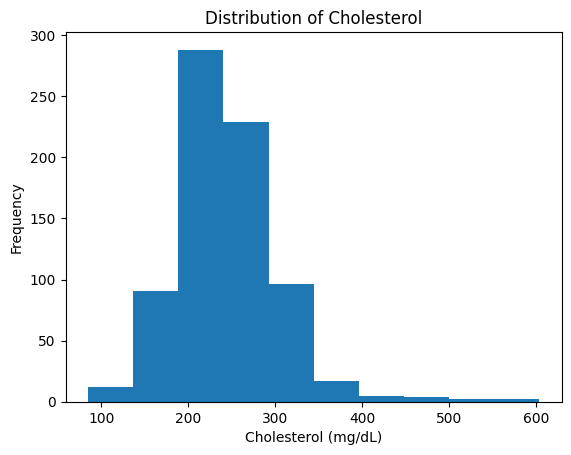

In [113]:
plt.hist(heart_df["Cholesterol"])
plt.title("Distribution of Cholesterol")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Frequency")
plt.show()

This distribution shows a positive skew (right skewed) with most cholesterol values concentrated at around 180-280 mg/dL, with a small number of patients having much higher values.

Since the data are skewed, the median is more robust to extreme values than the mean. (The mean would get pulled upwards by up to 600, but the median hardly changes). Hence, *median imputation* is chosen (most commonly used for clinical measurements).

In [114]:
#median imputation - fill in the missing values with the median of the available values in the column
chol_median = heart_df["Cholesterol"].median()
print(chol_median)

heart_df["Cholesterol"] = heart_df["Cholesterol"].fillna(chol_median)

heart_df["Cholesterol"].isna().sum()

237.0


np.int64(0)

Extra: explain why 0 mg/dL is not physiologically plausible.

## EDA and Data Visualization

1) How common is heart disease? (Bar chart)
2) Does age affext heart disease? (Histogram, boxplot)
3) Does sex affect heart disease? (Bar-chart, cross-tabulation)
4) Which chest pain type is most associated with heart disease? (Grouped bar chart)
5) Are patients with high choleterol more likely to have heart disease?
6) Does exercise-induced angina matter? Does it affect heart disease? (Bar Chart)
7) Does maximum heart rate differ? (Boxplot)
8) Relationships between variables (Correlation matrix, heatmap)

Suggestion:
- Pairplot (for multiple variables)
- Correlation ≠ Causation

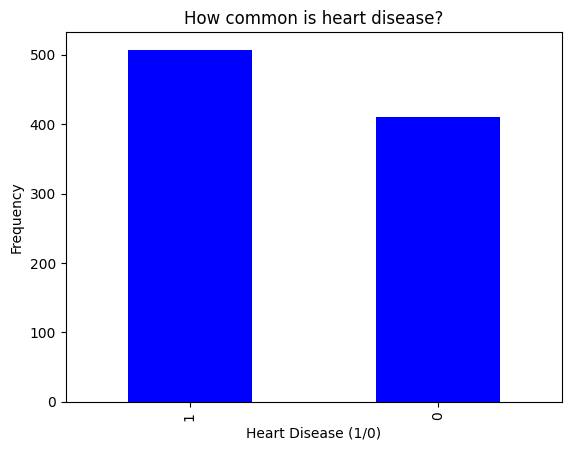

In [115]:
heart_df["HeartDisease"].value_counts().plot(kind="bar", color="blue")

plt.title("How common is heart disease?")
plt.xlabel("Heart Disease (1/0)")
plt.ylabel("Frequency")
plt.show()

Looking at the bar chart, heart disease are quite common.

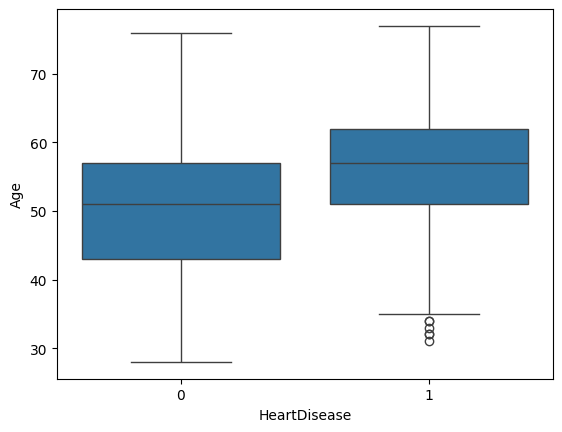

In [116]:
sns.boxplot(x="HeartDisease", y="Age", data=heart_df)
plt.show()

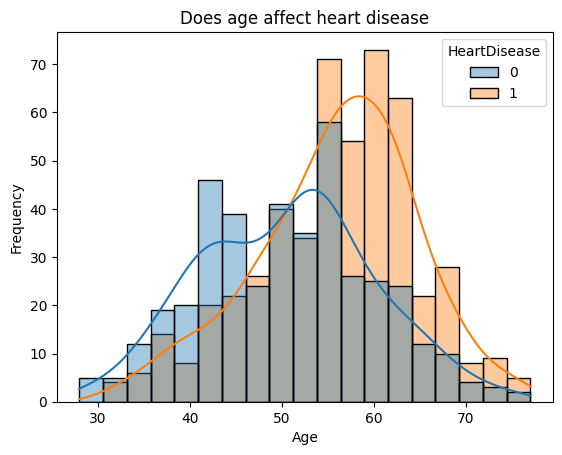

In [117]:
sns.histplot(data=heart_df, x="Age", hue="HeartDisease", kde=True, alpha=0.4)

plt.title("Does age affect heart disease")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Looking at the histogram and boxplot, people with heart disease peaked at age 55-65 (the median). While people who doesn't have heart disease peaked at age 40-45. This could suggest that older people who are 50 or older, are more likely to have heart disease, while people with age less than 50 are not likely to get heart disease. Furthermore, this could suggest that age does have an affect on heart disease.

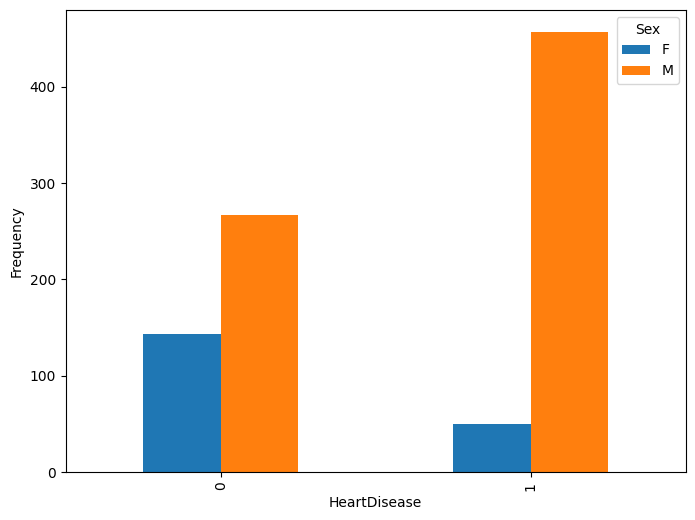

In [118]:
#cross-tabulation - works for both categorical variables
cross_tab = pd.crosstab(heart_df["HeartDisease"], heart_df["Sex"])

cross_tab.plot(kind="bar", figsize=(8, 6))
plt.ylabel("Frequency")
plt.show()

From the cross tabulation, it seems that males tend to have heart disease, while women are a lot less likely to have heart disease. This leads to a question: why do males tend to get heart disease?

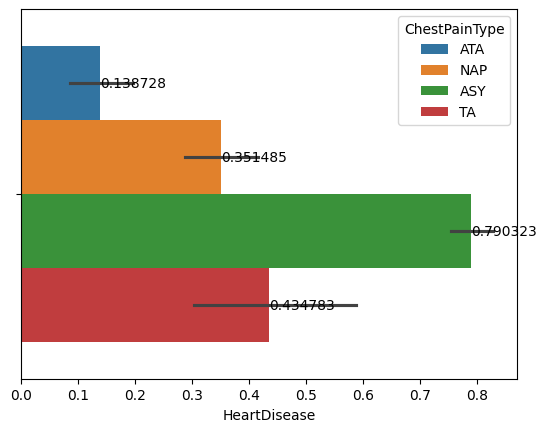

In [119]:
ax = sns.barplot(x="HeartDisease", hue="ChestPainType", data=heart_df)

#add labels to the bars
for container in ax.containers:
  ax.bar_label(container)

plt.show()

ASY is most associated with heart disease.

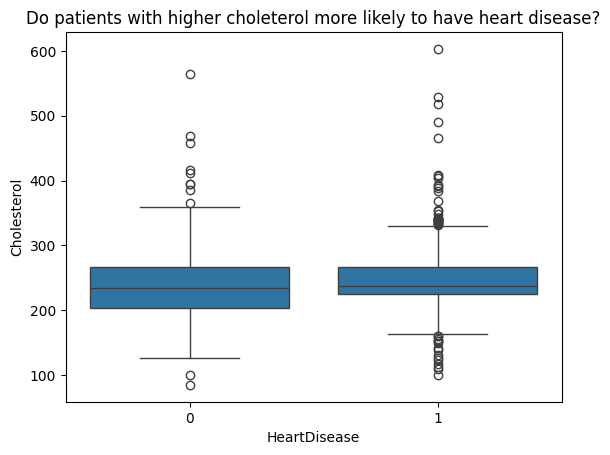

In [120]:
#Do patients with higher choleterol more likely to have heart disease?
sns.boxplot(x="HeartDisease", y="Cholesterol", data=heart_df)

plt.title("Do patients with higher choleterol more likely to have heart disease?")
plt.show()



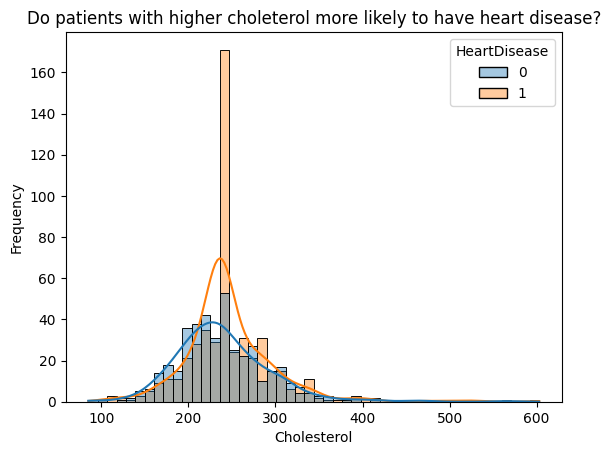

In [121]:
sns.histplot(data=heart_df, x="Cholesterol", hue="HeartDisease", kde=True, alpha=0.4)

plt.title("Do patients with higher choleterol more likely to have heart disease?")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()

The boxplot and the histogram shows that patients with or without heart disease have similar median of cholesteral, there are also outliers. This could mean that cholesterol might not directly affect heart disease.

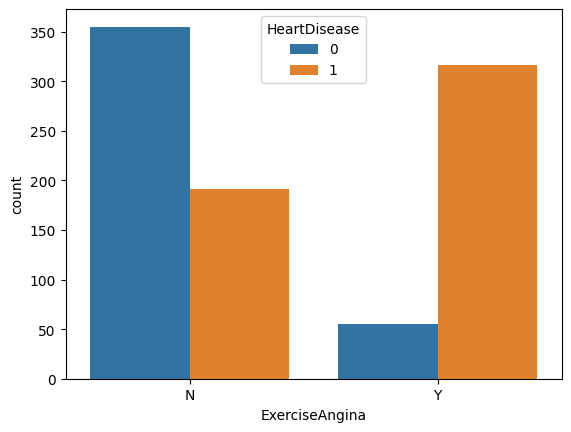

In [122]:
#Does exercise-induced angina matter? Does it affect heart disease?

sns.countplot(x="ExerciseAngina", hue="HeartDisease", data=heart_df)
plt.show()

From the countplot, it suggests that patients with exercise-angina have heart disease, while more people without exercise angina doesn't have heart disease. However, there are also quite a significant amount of patient with exercise angina who does have heart disease.

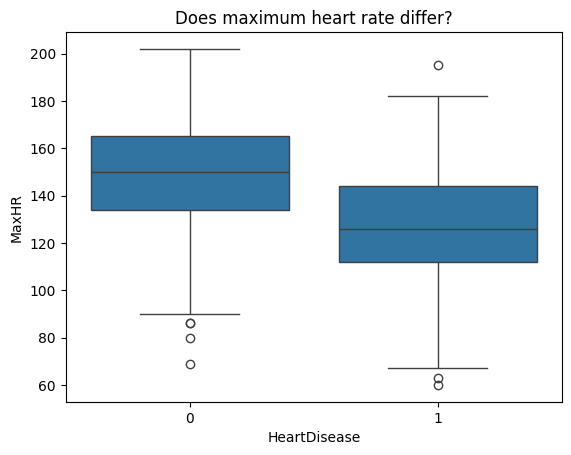

In [123]:
#Does maximum heart rate differ?

sns.boxplot(x="HeartDisease", y="MaxHR", data=heart_df)

plt.title("Does maximum heart rate differ?")
plt.show()

Patients who doesn't have heart disease tend to have a higher maximum heart rate, while patients with heart disease have a lower maximum heart rate. Furthermore, maximum heart rate are also related to age, younger people tend to have higher heart rate than older people. Therefore, this means that younger patients are less likely to have heart disease and older patients are more likely to have it. Addtionally, it further supports the point that age does have an affect on heart disease.

<function matplotlib.pyplot.show(close=None, block=None)>

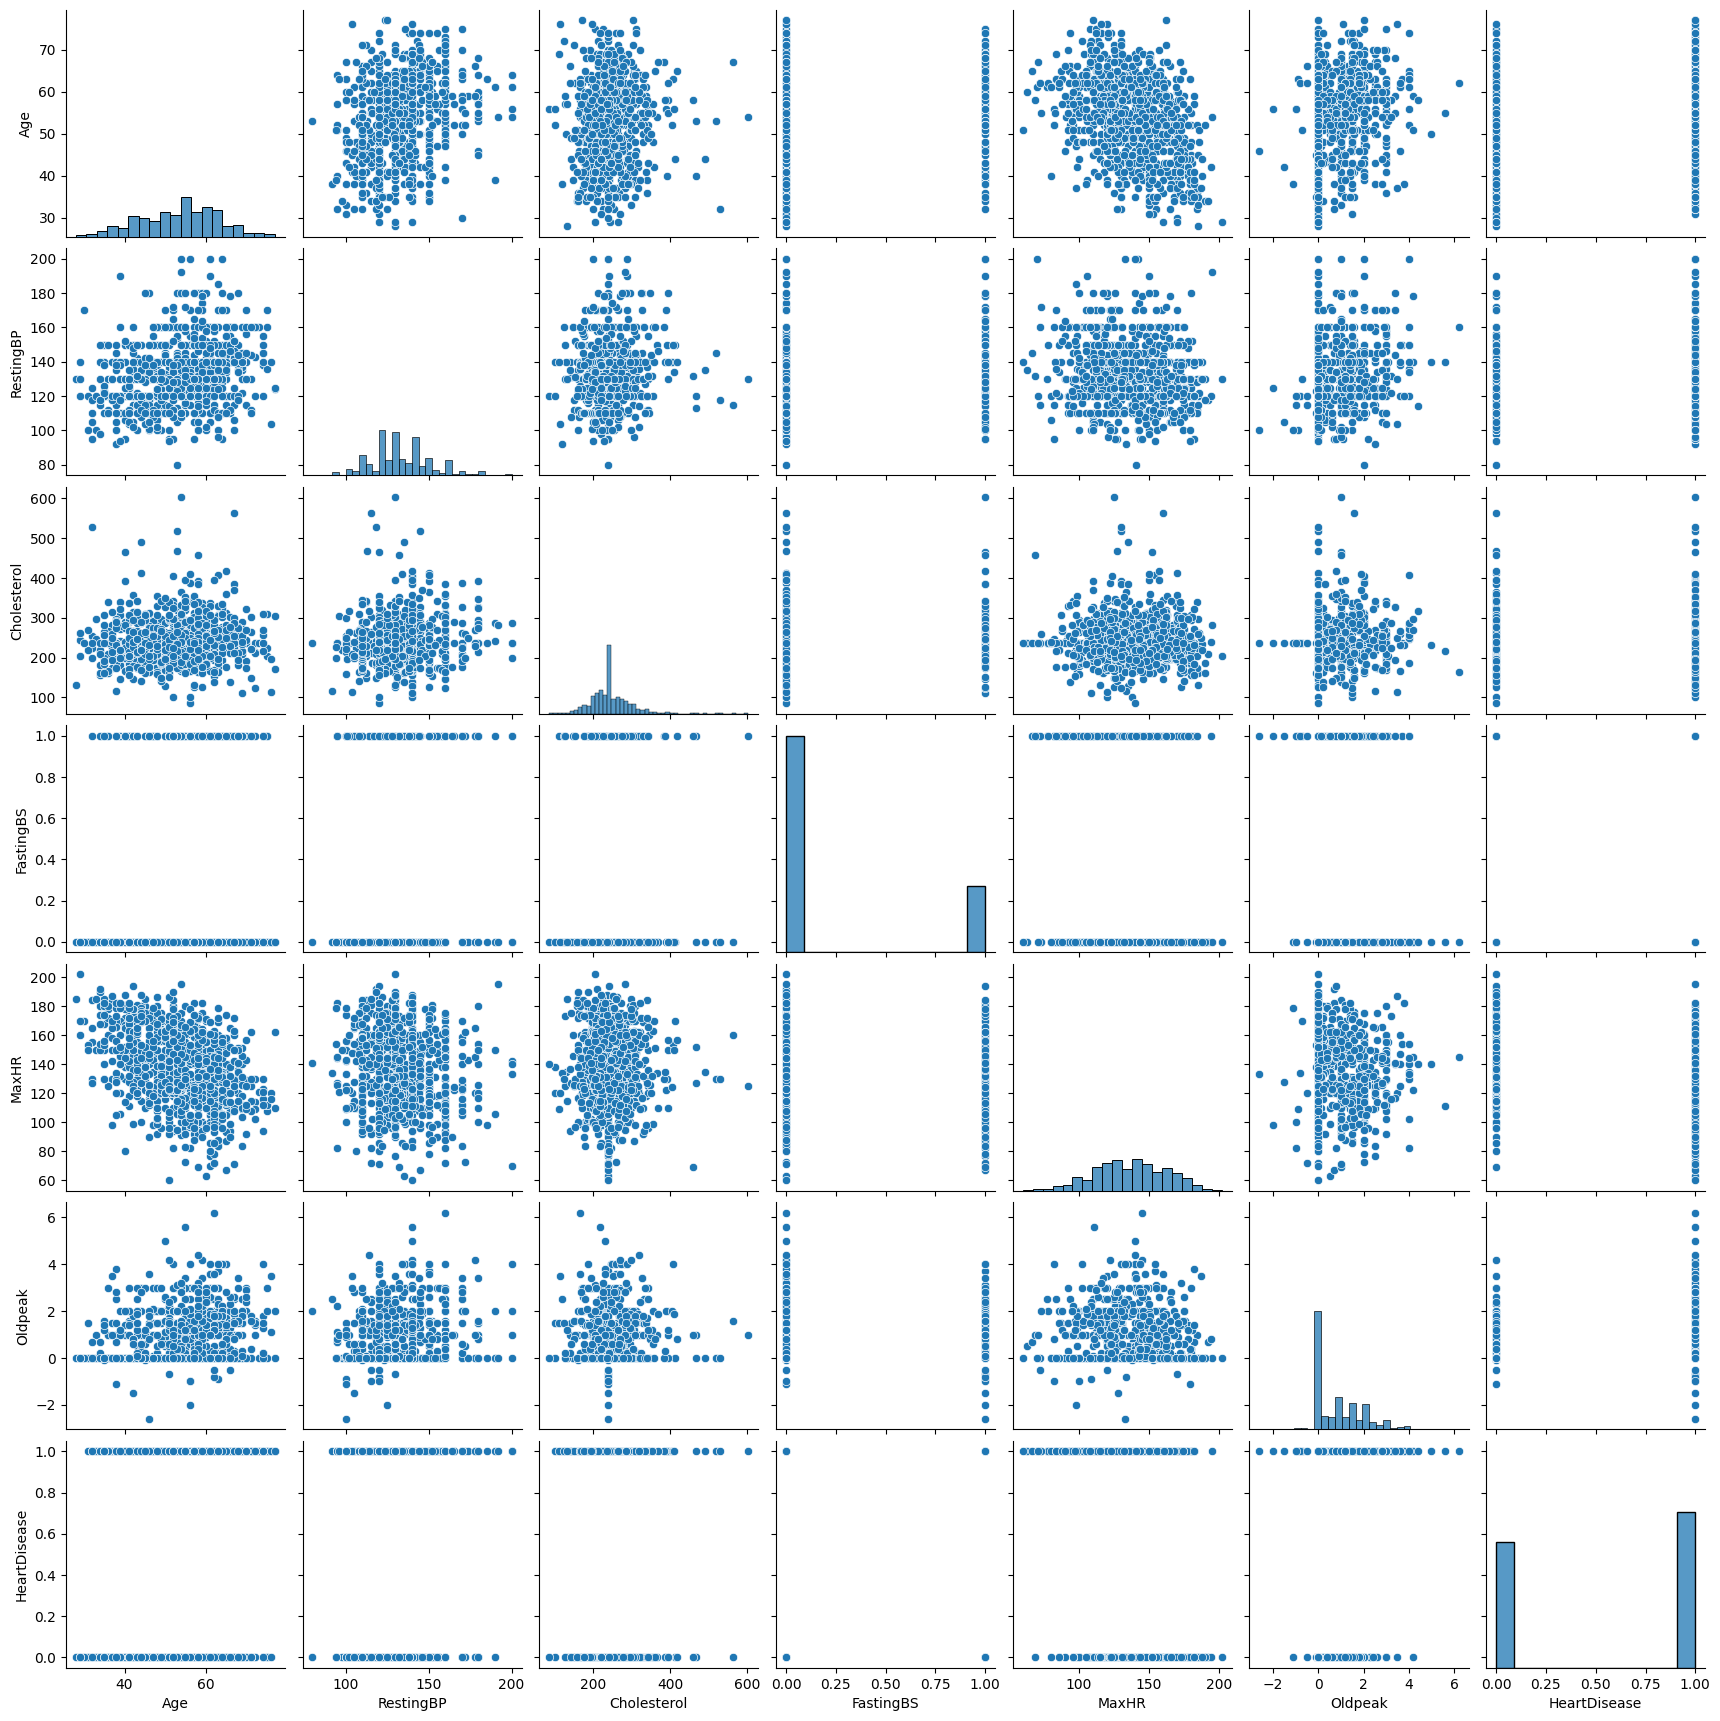

In [124]:
sns.pairplot(heart_df)
plt.show

One-hot encoding

In [125]:
from sklearn.preprocessing import OneHotEncoder

#reset the index of the original dataframe
heart_df = heart_df.reset_index(drop=True) #drop=True - throw away the old index instead of keeping it as a column

categorical_columns = heart_df.select_dtypes(include=["object"]).columns #select the columns with categorical values (objects/strings data types)

encoder = OneHotEncoder(sparse_output=False) #apply one hot encoder
# sparse_output=False means it returns a regular (dense) NumPy array

encoded_data = encoder.fit_transform(heart_df[categorical_columns]) #transform each category into set of 1/0 columns

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_columns)) #create new dataframe

final_df = pd.concat([heart_df.drop(columns=categorical_columns), encoded_df], axis=1) #remove the categorical columns and put in the encoded columns
#axis=1 means concatenate side-by-side as new columns (axis=0 would stack as new rows)

print(final_df)


     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0     40        140        289.0          0    172      0.0             0   
1     49        160        180.0          0    156      1.0             1   
2     37        130        283.0          0     98      0.0             0   
3     48        138        214.0          0    108      1.5             1   
4     54        150        195.0          0    122      0.0             0   
..   ...        ...          ...        ...    ...      ...           ...   
912   45        110        264.0          0    132      1.2             1   
913   68        144        193.0          1    141      3.4             1   
914   57        130        131.0          0    115      1.2             1   
915   57        130        236.0          0    174      0.0             1   
916   38        138        175.0          0    173      0.0             0   

     Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  \
0      0.0 

In [126]:
#calculate correlation
corr = final_df.corr()
corr

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
Age,1.000000,0.263084,0.045556,0.198170,-0.382280,0.258563,0.282012,-0.055670,0.055670,0.166903,...,-0.011681,0.032083,0.145837,-0.230793,0.136903,-0.216017,0.216017,0.138451,0.185499,-0.258027
RestingBP,0.263084,1.000000,0.086062,0.067823,-0.109693,0.174252,0.117990,-0.009427,0.009427,0.041568,...,-0.027536,0.049464,0.050648,-0.113759,0.089156,-0.153064,0.153064,-0.010323,0.110171,-0.105969
Cholesterol,0.045556,0.086062,1.000000,0.024851,-0.001510,0.054583,0.076262,0.111122,-0.111122,0.073971,...,-0.060496,-0.044694,0.084284,-0.043392,-0.032304,-0.072751,0.072751,-0.013993,0.087480,-0.081183
FastingBS,0.198170,0.067823,0.024851,1.000000,-0.131067,0.053062,0.267994,-0.120424,0.120424,0.130629,...,-0.038201,0.026752,-0.011965,-0.092588,0.126853,-0.059988,0.059988,0.104961,0.107683,-0.162346
MaxHR,-0.382280,-0.109693,-0.001510,-0.131067,1.000000,-0.161213,-0.401410,0.189668,-0.189668,-0.354444,...,0.133411,0.100235,0.126242,0.023181,-0.157561,0.370023,-0.370023,-0.073127,-0.343641,0.384339
Oldpeak,0.258563,0.174252,0.054583,0.053062,-0.161213,1.000000,0.403638,-0.105444,0.105444,0.280936,...,-0.107615,0.032382,0.087140,-0.117293,0.056283,-0.409494,0.409494,0.322371,0.282874,-0.450299
HeartDisease,0.282012,0.117990,0.076262,0.267994,-0.401410,0.403638,1.000000,-0.305118,0.305118,0.518339,...,-0.215311,-0.054591,0.011174,-0.092452,0.103067,-0.495490,0.495490,0.122852,0.553700,-0.621843
Sex_F,-0.055670,-0.009427,0.111122,-0.120424,0.189668,-0.105444,-0.305118,1.000000,-1.000000,-0.184631,...,0.067682,0.003903,0.049246,0.011098,-0.064009,0.191226,-0.191226,-0.066201,-0.115596,0.150537
Sex_M,0.055670,0.009427,-0.111122,0.120424,-0.189668,0.105444,0.305118,-1.000000,1.000000,0.184631,...,-0.067682,-0.003903,-0.049246,-0.011098,0.064009,-0.191226,0.191226,0.066201,0.115596,-0.150537
ChestPainType_ASY,0.166903,0.041568,0.073971,0.130629,-0.354444,0.280936,0.518339,-0.184631,0.184631,1.000000,...,-0.576929,-0.249442,0.001691,-0.062707,0.075916,-0.429495,0.429495,0.103157,0.305186,-0.360850


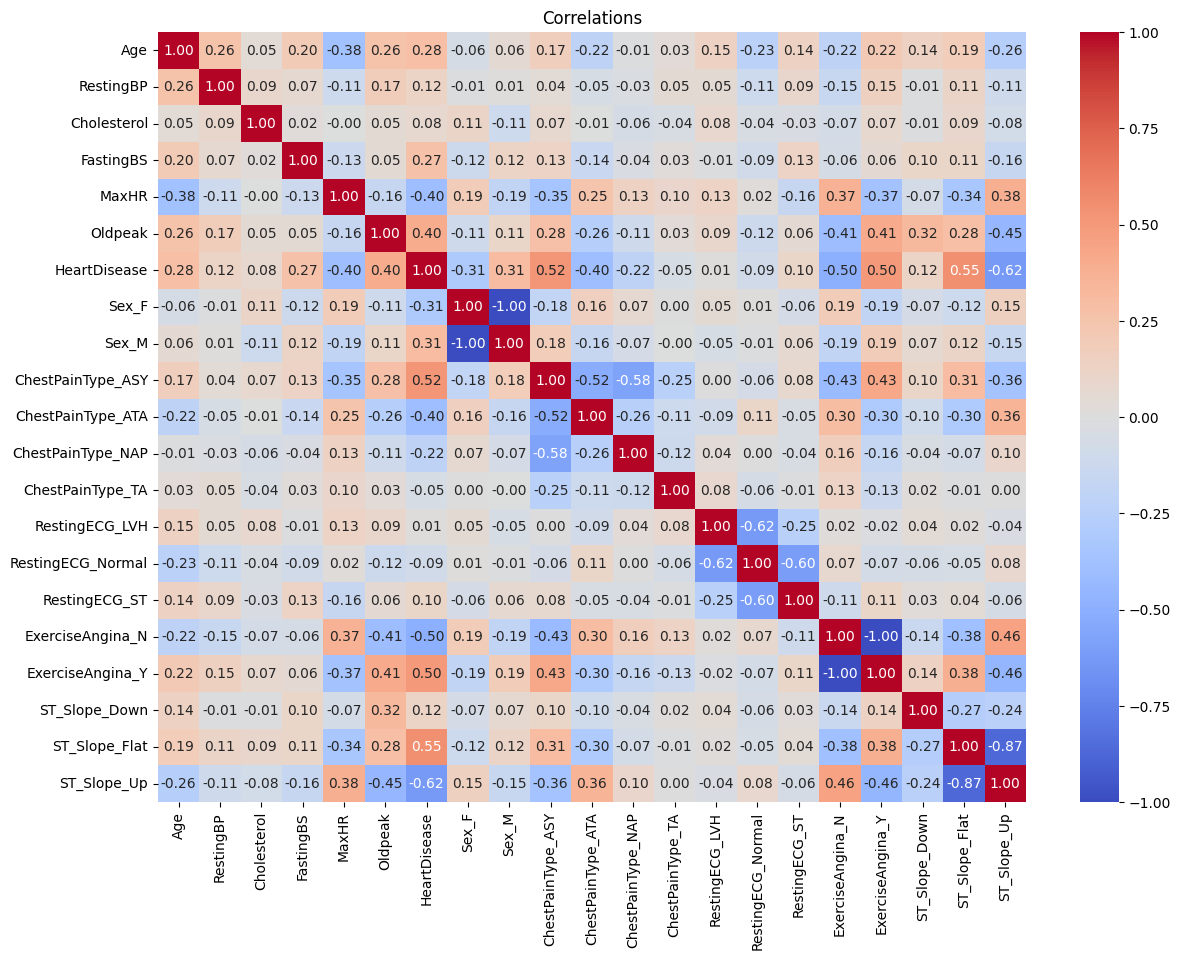

In [127]:
#Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm")
plt.title("Correlations")
plt.show()

Correlation between each variable and Heart disease (Target)

In [128]:
heartDisease_correlations = corr['HeartDisease'].sort_values(ascending=False)
print("Correlation between each variable and Heart disease (Target)")
print(heartDisease_correlations)

Correlation between each variable and Heart disease (Target)
HeartDisease         1.000000
ST_Slope_Flat        0.553700
ChestPainType_ASY    0.518339
ExerciseAngina_Y     0.495490
Oldpeak              0.403638
Sex_M                0.305118
Age                  0.282012
FastingBS            0.267994
ST_Slope_Down        0.122852
RestingBP            0.117990
RestingECG_ST        0.103067
Cholesterol          0.076262
RestingECG_LVH       0.011174
ChestPainType_TA    -0.054591
RestingECG_Normal   -0.092452
ChestPainType_NAP   -0.215311
Sex_F               -0.305118
MaxHR               -0.401410
ChestPainType_ATA   -0.401680
ExerciseAngina_N    -0.495490
ST_Slope_Up         -0.621843
Name: HeartDisease, dtype: float64


ChestPainType_ASY have a strong correlation with heart disease, this is also supported by the previous data visualization that ASY is most associated with heart disease out of all chest pain types. Furthermore from the correlation calculation, patients with exercise angina is also quite strongly related to heart disease, which is also supported by the visualization and supports the point that patients with exercise angina are more likely to have heart disease. Males are also correlated to heart disease more than female from the calculations, which means heart disease occurs more commonly in males.

## Data Scaling

Cross validation model comparison?? - to find which model is best

Model Evaluation

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Have to use the data with one hot encoding
#Drop target values
data = final_df.drop(columns=["HeartDisease"])
labels = final_df["HeartDisease"]

print("data shape:", data.shape)
print("label shape:", labels.shape)

data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.2, random_state=5)


data shape: (917, 20)
label shape: (917,)


In [130]:
#Data scaling

scaler = StandardScaler()

data_train_scaled = scaler.fit_transform(data_train)

data_test_scaled = scaler.transform(data_test)

print("Data_train:", data_train.shape)
print("Data_test:", data_test.shape)

Data_train: (733, 20)
Data_test: (184, 20)


In [131]:
print("Train class balance:")
print(labels_train.value_counts(normalize=True))

print("\nTest class balance:")
print(labels_test.value_counts(normalize=True))

Train class balance:
HeartDisease
1    0.54161
0    0.45839
Name: proportion, dtype: float64

Test class balance:
HeartDisease
1    0.597826
0    0.402174
Name: proportion, dtype: float64


## Model Training

This is a ***classification*** problem

For each model you plan to use, answer these questions:

- What is the basic idea behind the algorithm?
- What kinds of data does it work well on?
- What are its strengths?
- What are its weaknesses?
- Why is it a reasonable choice for this heart disease dataset?

In [132]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Logistic Regression

In [133]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

# penalty = 'l2'
# C = 1
# solver = 'lbfgs'
# multi_class = 'ovr'

logistic_regression = LogisticRegression()

logistic_regression.fit(data_train_scaled, labels_train)


LogisticRegression()

Logistic regression test accuracy: 87.5%
Logistic regression train accuracy: 86.08458390177354%
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        74
           1       0.91      0.87      0.89       110

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



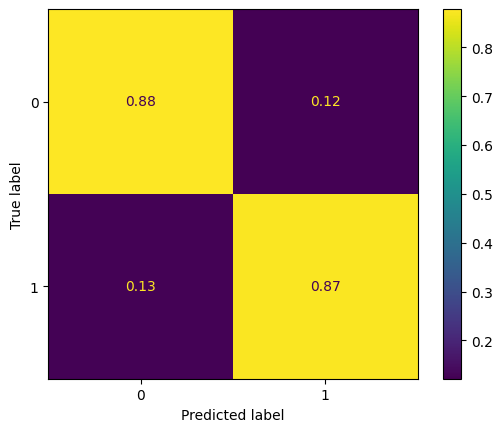

In [134]:
logistic_regression_predictions = logistic_regression.predict(data_test_scaled)

#test accuracy
test_acc = accuracy_score(labels_test, logistic_regression_predictions)
print(f"Logistic regression test accuracy: {test_acc * 100}%")

logistic_regression_train_predictions = logistic_regression.predict(data_train_scaled)

train_acc = accuracy_score(labels_train, logistic_regression_train_predictions)
print(f"Logistic regression train accuracy: {train_acc * 100}%")

#classification report
print(classification_report(labels_test, logistic_regression_predictions))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, logistic_regression_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()


Test accuracy is higher than train accuracy - no overfitting.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


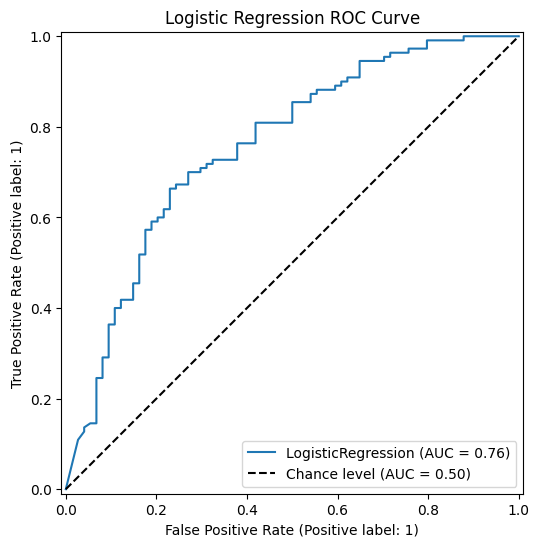

In [135]:
#ROC Curve
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(logistic_regression, data_test, labels_test, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.50)")
ax.set_title("Logistic Regression ROC Curve")
ax.legend()
plt.show()


Decision Tree

decision tree test accuracy: 81.52173913043478%
decision tree train accuracy: 100.0%
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        74
           1       0.86      0.83      0.84       110

    accuracy                           0.82       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184



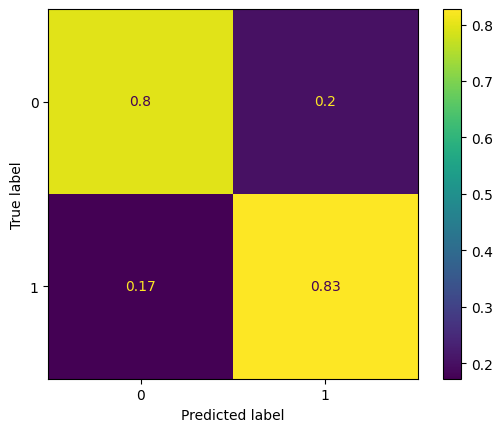

In [136]:
from sklearn import tree

decision_tree = tree.DecisionTreeClassifier()
decision_tree.fit(data_train_scaled, labels_train)

#accuracy score
decision_tree_predictions = decision_tree.predict(data_test_scaled)
test_acc = accuracy_score(labels_test, decision_tree_predictions)
print(f"decision tree test accuracy: {test_acc * 100}%")

decision_tree_train_predictions = decision_tree.predict(data_train_scaled)
train_acc = accuracy_score(labels_train, decision_tree_train_predictions)
print(f"decision tree train accuracy: {train_acc * 100}%")

#classification report
print(classification_report(labels_test, decision_tree_predictions))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, decision_tree_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()



train accuracy 100% - overfitting

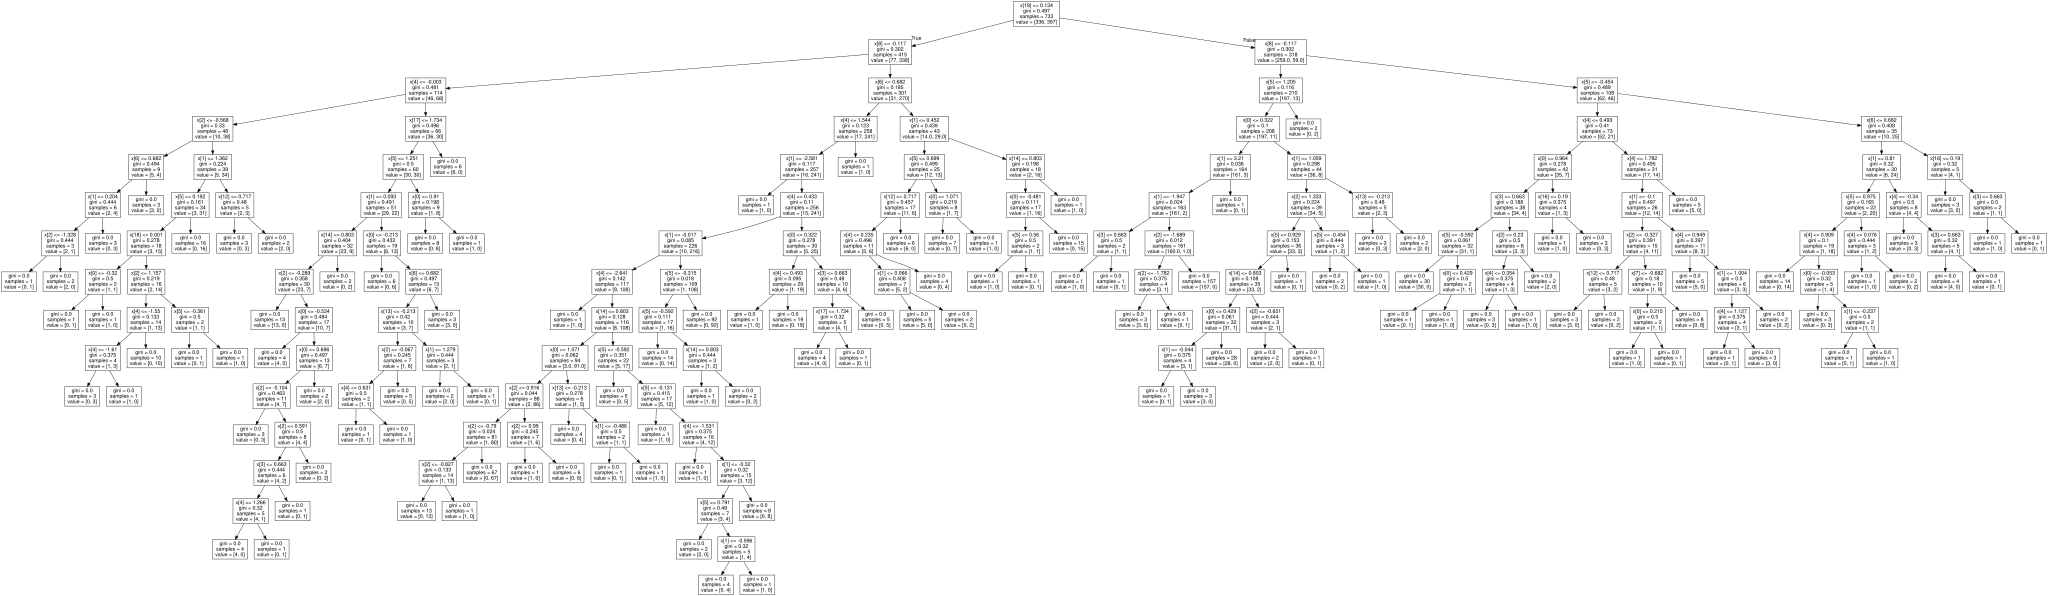

In [137]:
#Plot decision tree
import graphviz

dot = tree.export_graphviz(decision_tree, out_file=None)
graph = graphviz.Source(dot)
graph

Random Forest

Random Forest test accuracy score: 89.13043478260869%
Random Forest train accuracy score: 100.0%
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        74
           1       0.90      0.92      0.91       110

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.89       184
weighted avg       0.89      0.89      0.89       184



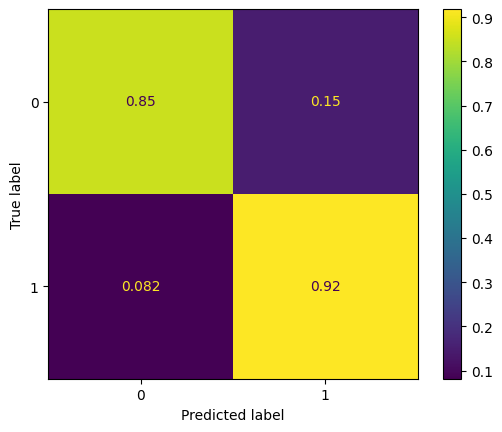

In [138]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()
random_forest.fit(data_train_scaled, labels_train)

random_forest_prediction = random_forest.predict(data_test_scaled)

#accuracy score
test_acc = accuracy_score(labels_test, random_forest_prediction)
print(f"Random Forest test accuracy score: {test_acc * 100}%")

random_forest_train_prediction = random_forest.predict(data_train_scaled)
train_acc = accuracy_score(labels_train, random_forest_train_prediction)
print(f"Random Forest train accuracy score: {train_acc * 100}%")

#classification report
print(classification_report(labels_test, random_forest_prediction))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, random_forest_prediction)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()


Train more than test - overfitting

SVM

Test accuracy score for SVM: 88.04347826086956%
Train accuracy score for SVM: 89.7680763983629%
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        74
           1       0.90      0.90      0.90       110

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



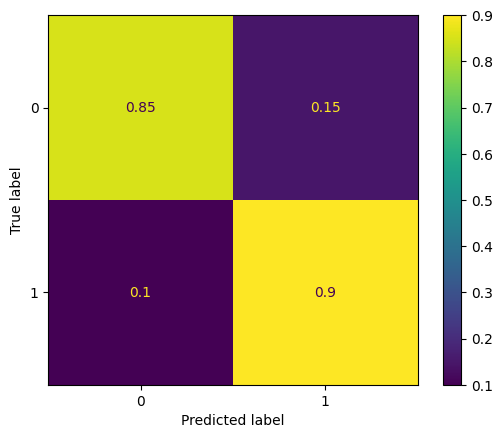

In [139]:
from sklearn.svm import SVC

# kernel = "rbf"
# degree = 3
# C = 5
# coef0 = 1

svm = SVC()

svm.fit(data_train_scaled, labels_train)

svm_predictions = svm.predict(data_test_scaled)

#accuracy score
test_acc = accuracy_score(labels_test, svm_predictions)
print(f"Test accuracy score for SVM: {test_acc * 100}%")

svm_train_predictions = svm.predict(data_train_scaled)
train_acc = accuracy_score(labels_train, svm_train_predictions)
print(f"Train accuracy score for SVM: {train_acc * 100}%")

#classification report
print(classification_report(labels_test, svm_predictions))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, svm_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()

KNN

Test accuracy score for KNN: 87.5%
Train accuracy score for KNN: 87.58526603001364%
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        74
           1       0.91      0.87      0.89       110

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



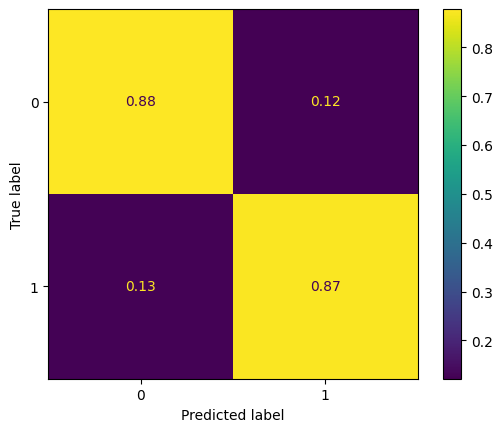

In [140]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5) #5 is default - how many nearest neighbors to look at when voting on a class
knn.fit(data_train_scaled, labels_train)

knn_predictions = knn.predict(data_test_scaled)

#Accuracy Score
test_acc = accuracy_score(labels_test, knn_predictions)
print(f"Test accuracy score for KNN: {test_acc * 100}%")

knn_train_predictions = knn.predict(data_train_scaled)
train_acc = accuracy_score(labels_train, knn_train_predictions)
print(f"Train accuracy score for KNN: {train_acc * 100}%")

#Classification Report
print(classification_report(labels_test, knn_predictions))

#Confusion Matrix
conf_matrix = confusion_matrix(labels_test, knn_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()

Gradient Boosting

Test accuracy score for Gradient Boosting: 88.58695652173914%
Train accuracy score for Gradient Boosting: 95.22510231923602%
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        74
           1       0.92      0.89      0.90       110

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



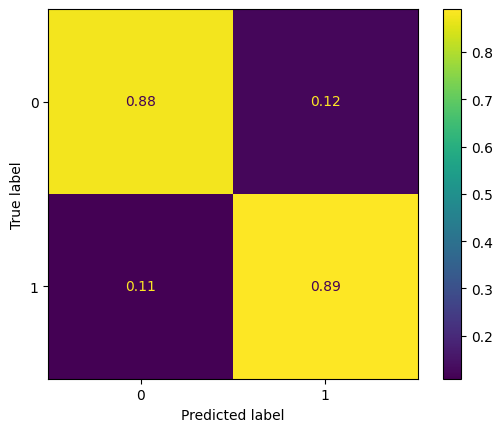

In [141]:
#gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

# n_estimators = 300,
# learning_rate = 0.05,
# random_state = 5,
# max_features = 5

gbc = GradientBoostingClassifier()

gbc.fit(data_train_scaled, labels_train)

gbc_predictions = gbc.predict(data_test_scaled)

#Accuracy
test_acc = accuracy_score(labels_test, gbc_predictions)
print(f"Test accuracy score for Gradient Boosting: {test_acc*100}%")

gbc_train_predictions = gbc.predict(data_train_scaled)
train_acc = accuracy_score(labels_train, gbc_train_predictions)
print(f"Train accuracy score for Gradient Boosting: {train_acc*100}%")

#classification report
print(classification_report(labels_test, gbc_predictions))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, gbc_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()


## Model Evaluation

Use cross-validation to estimate how well each model performs

Compare models using several metrics, such as:

- Accuracy
- Precision
- Recall (Sensitivity)
- F1-score
- ROC-AUC

For a medical diagnosis task, recall is particularly important because it measures how many patients with heart disease the model correctly identifies.

(Note:Learn what each metric means especially the ones in the classification report)

Cross validation

In [142]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

#Define cross-validation strategy
#StratifiedKFold keeps the same class proportions in each fold as in the full dataset
#important for classification, especially if classes are imbalanced

cross_validate = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

#put models in dictionary to loop through them
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": tree.DecisionTreeClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(),
}

#Run cross-validation for each model
for name, model in models.items():
  scores = cross_val_score(model, data_train_scaled, labels_train, cv=cross_validate, scoring='accuracy')
  print(f"{name}:")
  print(f"Fold Accuracies: {np.round(scores, 3)}")
  print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
  print(f"Std deviation: {scores.std() * 100:.2f}%\n")


Logistic Regression:
Fold Accuracies: [0.837 0.85  0.823 0.849 0.877]
Mean Accuracy: 84.72%
Std deviation: 1.77%

Decision Tree:
Fold Accuracies: [0.755 0.776 0.769 0.774 0.781]
Mean Accuracy: 77.08%
Std deviation: 0.88%

SVM:
Fold Accuracies: [0.85  0.857 0.816 0.842 0.897]
Mean Accuracy: 85.27%
Std deviation: 2.62%

KNN:
Fold Accuracies: [0.837 0.857 0.837 0.836 0.842]
Mean Accuracy: 84.17%
Std deviation: 0.81%

Gradient Boosting:
Fold Accuracies: [0.864 0.878 0.83  0.842 0.884]
Mean Accuracy: 85.95%
Std deviation: 2.04%



| Model               | Mean Accuracy |   Std Dev | Interpretation                                       |
| ------------------- | ------------: | --------: | ---------------------------------------------------- |
| Logistic Regression |    **84.72%** | **1.77%** | Good accuracy, fairly consistent                     |
| Decision Tree       |    **76.54%** | **1.89%** | Lowest accuracy, likely underperforming              |
| SVM                 |    **85.27%** | **2.62%** | High accuracy, but more variable                     |
| KNN                 |    **84.17%** | **0.81%** | Slightly lower accuracy, very consistent             |
| Gradient Boosting   |    **85.95%** | **2.04%** | Highest average accuracy with reasonable consistency |


From the cross validation, gradient boosting acheived the highest mean accuracy (85.95%) with a relatively low standard deviation (2.04%), suggesting that it provides the best balance between predictive performance and consistency among the evaluated models.

Gradient boosting, SVM and Logistic Regression achieved the highest mean accuracies therefore they were chosen for further evaluation.

Hyperparameter Tuning

In [143]:
#Gradient Boosting - hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}

gb_model = GradientBoostingClassifier()

grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)

grid_search.fit(data_train, labels_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(data_test)

accuracy_best = accuracy_score(labels_test, y_pred_best)

print("Best Parameters:", best_params)
print(f"Best Model Accuracy: {accuracy_best}")

Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best Model Accuracy: 0.8532608695652174


Gradient boosting: The model's accuracy on the test set is approximately 91.30%, which improved from 88.56%.

In [144]:
#Non-linear SVM - GridSearchCV
param_grid = {'C': [0.1, 1, 10, 100, 1000],
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
			'kernel': ['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

grid.fit(data_train, labels_train)

svm_best_param = grid.best_params_
svm_best_estimator = grid.best_estimator_

print("Best parameter: ",svm_best_param)
print("Best Model Accuracy",svm_best_estimator)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.544 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.544 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.537 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.541 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.541 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.544 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.544 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.537 total time=   0.1s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.541 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.541 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.544 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

In [151]:
#Logistic Regression - RandomizedSearchCV (faster than GridSearchCV)
from sklearn.model_selection import RandomizedSearchCV

param_distributions = [
    {
        'penalty': ['l2', None],
        'C': np.logspace(-4, 4, 10),
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'max_iter': [1000]
    },
    {
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-4, 4, 10),
        'solver': ['liblinear'],
        'max_iter': [1000]
    },
    {
        'penalty': ['l1', 'l2', 'elasticnet', None],
        'C': np.logspace(-4, 4, 10),
        'solver': ['saga'],
        'l1_ratio': [0.0, 0.5, 1.0],
        'max_iter': [1000]
    }
]

clf = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    verbose=True,
    n_jobs=-1,
    random_state=5
)

best_clf = clf.fit(data_train, labels_train)
log_best_params = best_clf.best_params_
print(log_best_params)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'C': np.float64(2.782559402207126)}


Train Model with best hyperparameters

Test accuracy score for Gradient Boosting: 85.32608695652173%
Train accuracy score for Gradient Boosting: 98.36289222373806%
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        74
           1       0.91      0.84      0.87       110

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



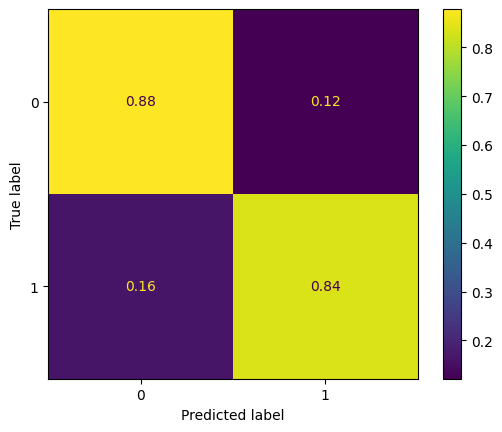

In [146]:
#gradient boosting

gbc = GradientBoostingClassifier(**best_params)

gbc.fit(data_train_scaled, labels_train)

gbc_predictions = gbc.predict(data_test_scaled)

#Accuracy
test_acc = accuracy_score(labels_test, gbc_predictions)
print(f"Test accuracy score for Gradient Boosting: {test_acc*100}%")

gbc_train_predictions = gbc.predict(data_train_scaled)
train_acc = accuracy_score(labels_train, gbc_train_predictions)
print(f"Train accuracy score for Gradient Boosting: {train_acc*100}%")

#classification report
print(classification_report(labels_test, gbc_predictions))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, gbc_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()

Test accuracy score for SVM: 85.86956521739131%
Train accuracy score for SVM: 86.3574351978172%
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        74
           1       0.89      0.87      0.88       110

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.86      0.86       184



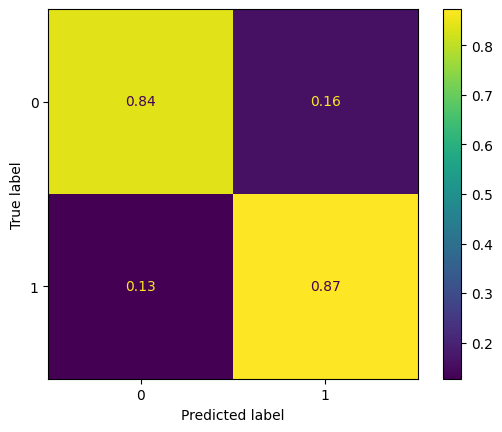

In [147]:
#SVM

svm = SVC(**svm_best_param)

svm.fit(data_train_scaled, labels_train)

svm_predictions = svm.predict(data_test_scaled)

#accuracy score
test_acc = accuracy_score(labels_test, svm_predictions)
print(f"Test accuracy score for SVM: {test_acc * 100}%")

svm_train_predictions = svm.predict(data_train_scaled)
train_acc = accuracy_score(labels_train, svm_train_predictions)
print(f"Train accuracy score for SVM: {train_acc * 100}%")

#classification report
print(classification_report(labels_test, svm_predictions))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, svm_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()

Logistic regression test accuracy: 87.5%
Logistic regression train accuracy: 86.08458390177354%
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        74
           1       0.91      0.87      0.89       110

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



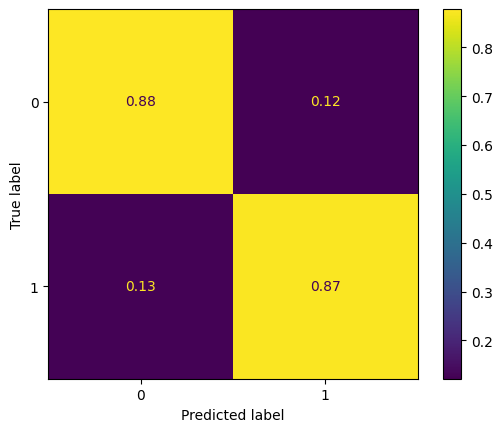

In [152]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(**log_best_params)

logistic_regression.fit(data_train_scaled, labels_train)

logistic_regression_predictions = logistic_regression.predict(data_test_scaled)

#test accuracy
test_acc = accuracy_score(labels_test, logistic_regression_predictions)
print(f"Logistic regression test accuracy: {test_acc * 100}%")

logistic_regression_train_predictions = logistic_regression.predict(data_train_scaled)

train_acc = accuracy_score(labels_train, logistic_regression_train_predictions)
print(f"Logistic regression train accuracy: {train_acc * 100}%")

#classification report
print(classification_report(labels_test, logistic_regression_predictions))

#confusion matrix
conf_matrix = confusion_matrix(labels_test, logistic_regression_predictions)
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

labels = np.unique(labels_test)

conf_matrix_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                          display_labels=labels)
conf_matrix_disp.plot()
plt.show()


| Model               | Accuracy | Precision (Class1) | Recall (Class1) | F1-score (Class1) |
| ------------------- | -------: | --------: | -----: | -------: |
| Logistic Regression |      88% |       91% |    87% |      89% |
| SVM                 |      86% |       89%|    87% |      88% |
| Gradient Boosting   |      85% |       91% |    84% |      87% |


For this project, we're going to evaluate models based on the accuracy score and recall score. Recall measures how many sick patients the model successfully identify. In this project, which is about healthcare, recall is the most important metric because missing a patient with heart disease will lead to serious consequences.

From the classification report, logistic regression is the best model with the highest accuracy (88%) and a recall score of 87%. SVM have the same recall score but less accuracy, thus Logistic is better. However, it is worth noting that from the testing and training accuracy score of SVM and Gradient Boosting, they have a higher training accuracy score than testing accuracy, which means that they are more prone to overfitting and will not generalize well. Logistic regression have lower train accuracy score than testing accuracy, which means the model are less likely to overfit and will generalize well.